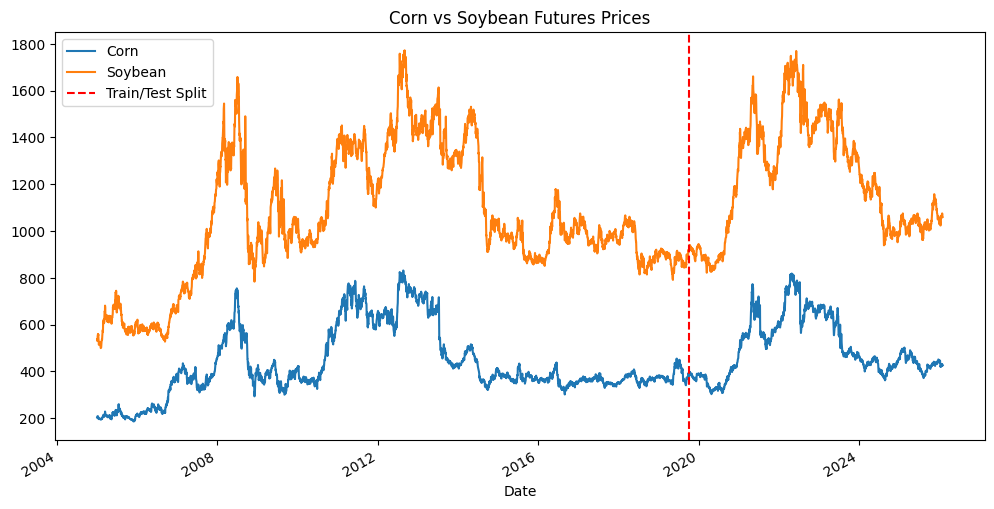

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\data\daily_corn_prices.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['Close']

df2=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\data\daily_soybean_prices.csv', skiprows=[1], index_col=0, parse_dates=True)
soybean=df2['Close']

df=pd.merge(left=corn, right=soybean, left_index=True, right_index=True, how='inner')
df.columns=['Corn', 'Soybean']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Corn vs Soybean Futures Prices')
plt.legend()
plt.show()


In [21]:
adf_corn=adfuller(df_train['Corn'])
adf_soybean=adfuller(df_train['Soybean'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'Critical Values: {adf_soybean[4]}')

ADF Statistic for Corn: -2.0510748310015594
p-value for Corn: 0.2646369229222719
ADF Statistic for Soybean: -2.4232965313063146
p-value for Soybean: 0.1352687963790532
Critical Values: {'1%': -3.4321248463781306, '5%': -2.862324228723766, '10%': -2.5671874564323343}


In [24]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'Critical Values: {adf_soybean_diff[4]}')

ADF Statistic for Corn: -13.265508877822047
p-value for Corn: 8.234102570600015e-25
ADF Statistic for Soybean: -12.527458469047572
p-value for Soybean: 2.4705439183901883e-23
Critical Values: {'1%': -3.4321248463781306, '5%': -2.862324228723766, '10%': -2.5671874564323343}


                            OLS Regression Results                            
Dep. Variable:                Soybean   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                 1.294e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:25:40   Log-Likelihood:                -23356.
No. Observations:                3712   AIC:                         4.672e+04
Df Residuals:                    3710   BIC:                         4.673e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        328.2656      6.598     49.756      0.0

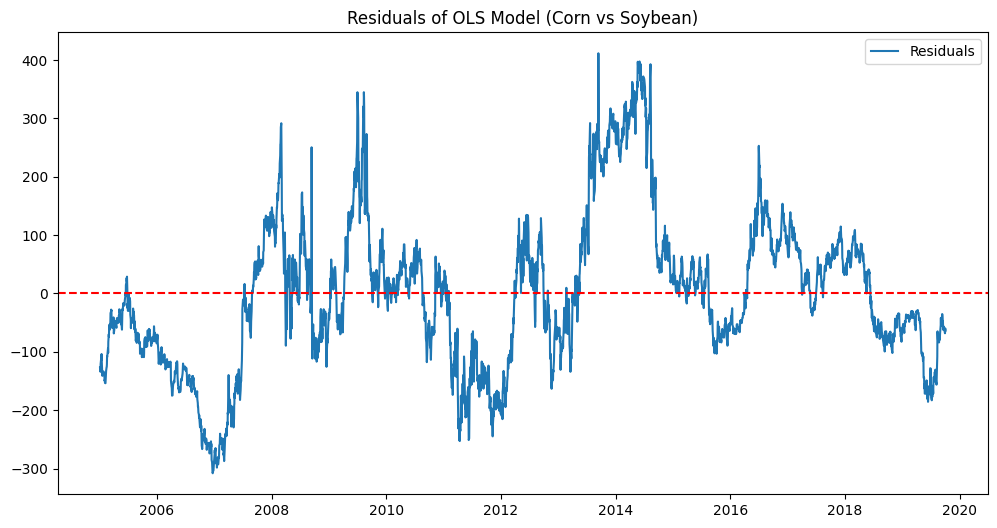

In [51]:
X_1=sm.add_constant(df_train['Corn'])
y_1=df_train['Soybean']
model_1=sm.OLS(y_1,X_1)
result_1=model_1.fit()
print(result_1.summary())

plt.figure(figsize=(12, 6))

plt.plot(result_1.resid, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of OLS Model (Corn vs Soybean)')
plt.legend()
plt.show()


In [48]:
adf_residuals_1=adfuller(result_1.resid, maxlag=1)
print(f'ADF Statistic for residuals: {adf_residuals_1[0]}')
print(f'p-value for residuals: {adf_residuals_1[1]}')
print(f'Critical Values: {adf_residuals_1[4]}')

ADF Statistic for residuals: -3.788970536148042
p-value for residuals: 0.003022198279214673
Critical Values: {'1%': -3.4321138356601963, '5%': -2.8623193649997063, '10%': -2.567184867154409}


In [49]:
X_2=sm.add_constant(df_train['Soybean'])
y_2=df_train['Corn']
model_2=sm.OLS(y_2,X_2)
result_2=model_2.fit()
print(result_2.summary())

adf_residuals_2=adfuller(result_2.resid, maxlag=1)
print(f'ADF Statistic for residuals: {adf_residuals_2[0]}')
print(f'p-value for residuals: {adf_residuals_2[1]}')
print(f'Critical Values: {adf_residuals_2[4]}')

                            OLS Regression Results                            
Dep. Variable:                   Corn   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                 1.294e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:22:42   Log-Likelihood:                -20997.
No. Observations:                3712   AIC:                         4.200e+04
Df Residuals:                    3710   BIC:                         4.201e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -58.2693      4.409    -13.215      0.0

## CADF Test Results

We tested both variable orderings following Chan (2013) Example 2.6.

| Order | ADF Statistic | p-value | Conclusion |
|-------|--------------|---------|------------|
| Soybean = β*Corn + μ | -3.789 | 0.003 | Cointegrated |
| Corn = β*Soybean + μ | -3.696 | 0.004 | Cointegrated |

Both orderings confirm cointegration at the 95% confidence level.
We select **Order 1 (Soybean as dependent variable)** because it produces 
the more negative t-statistic (-3.789 vs -3.696), as recommended by the book.

The spread for the rest of the analysis is:
$$Spread = Soybean - 1.6645 \times Corn - 328.27$$